# 04. Forced photometry on Spitzer/IRAC

The IRAC point response function (PRF) is 1.7 to 2.0 arcsec wide, so
neighbouring Euclid sources often blend. As for unWISE in
[notebook 03](03_wise_forced_photometry.ipynb), the VIS source models of
[notebook 01](01_multiband_forced_photometry.ipynb) are held fixed,
convolved with the IRAC PRF, and their fluxes are fitted together with the
background.

The IRAC PRF varies across the detector, and each mosaic pixel combines
exposures taken at different detector positions and orientations. The
effective PRF therefore changes across the mosaic. It is rebuilt on a grid
from the detector PRFs of the
[IRAC Instrument Handbook](https://irsa.ipac.caltech.edu/data/SPITZER/docs/irac/iracinstrumenthandbook/19/#_Toc82083619)
and the exposures contributing to the mosaic, following
[PRFMAP](https://github.com/cosmic-dawn/prfmap).

The field is a 200 arcsec region of EDF-F. IRAC1 to IRAC4 are channels 1
to 4, at 3.6, 4.5, 5.8 and 8.0 µm.

In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))

import numpy as np
import matplotlib.pyplot as plt

import euclid_phot as ep
from euclid_phot import irac

DATA_DIR = Path(os.environ["EUCLID_PHOT_DATA_DIR"])
IRAC_DIR = DATA_DIR / "irac"
RUN_NAME = "edff-irac-demo"
TARGET_RA, TARGET_DEC = 52.932, -28.088
SIZE_ARCSEC = 200.0
CHANNELS = ("IRAC1", "IRAC2", "IRAC3", "IRAC4")
WISE_BANDS = ("W1", "W2")
MOSAIC_BACKEND = "dawn"
DAWN_FIELD = "EDFF"
N_WORKERS = 10

## 1. Input images

`MOSAIC_BACKEND` selects the IRAC images:

- `"dawn"`: the deep [Cosmic Dawn Survey](https://irsa.ipac.caltech.edu/data/SPITZER/Cosmic_Dawn/)
  mosaics, available only in the survey fields.
- `"seip"`: the [SEIP Super Mosaics](https://irsa.ipac.caltech.edu/data/SPITZER/Enhanced/SEIP/),
  with wider archive coverage.
- `"pbcd"`: Level 2 mosaics of single observations from the
  [Spitzer Heritage Archive](https://irsa.ipac.caltech.edu/docs/knowledgebase/spitzer_sha.html),
  for fields outside the other two.

The observed images confirm the position and coverage before the fit.

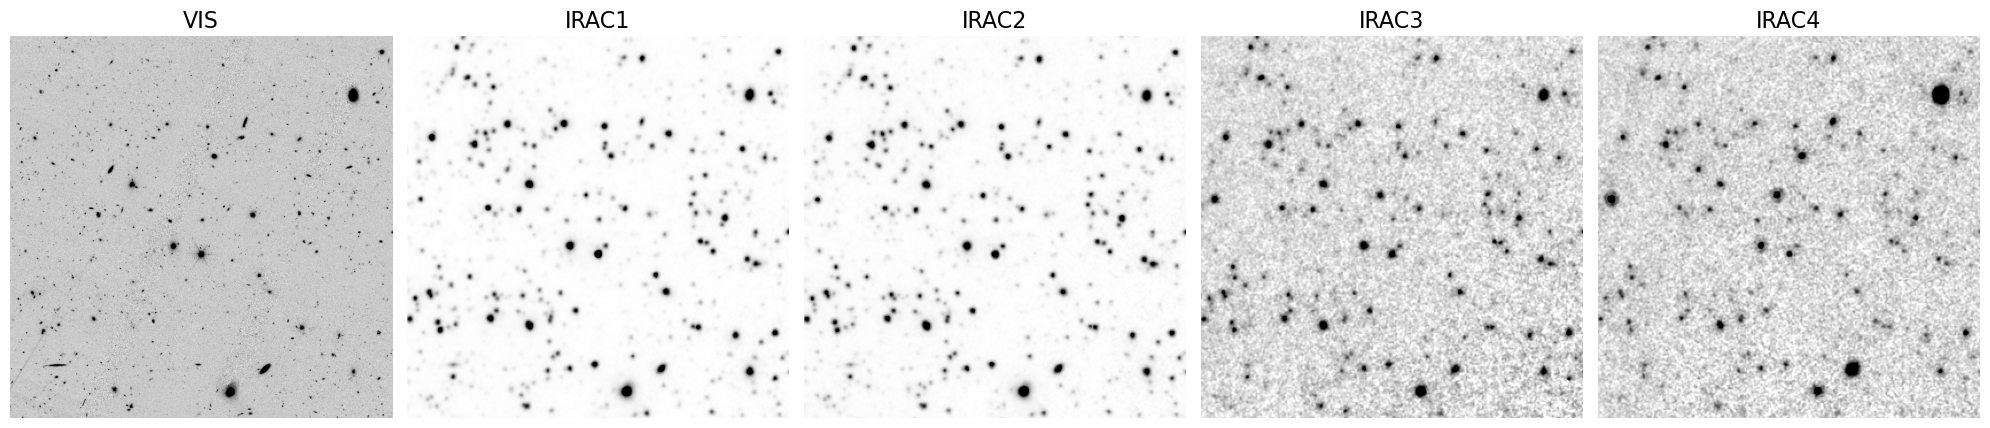

In [2]:
vis = ep.fetch_cutout("VIS", TARGET_RA, TARGET_DEC, SIZE_ARCSEC,
                      data_dir=DATA_DIR / "cutouts")
images = {"VIS": vis.data}
for channel in CHANNELS:
    mosaic = irac.fetch_irac_mosaic(TARGET_RA, TARGET_DEC, channel,
                                    size_arcsec=SIZE_ARCSEC,
                                    mosaic_backend=MOSAIC_BACKEND,
                                    data_root=IRAC_DIR)
    images[channel] = mosaic.cutout.data_ujy
irac.viz.show_inputs(images)
plt.show()

## 2. VIS models and IRAC fit

`run_irac_photometry` fits the VIS scene with the model-selection tree,
builds the effective PRF of each channel, and fits the VIS models to the
IRAC pixels. The fluxes and a background are free, and each centroid may
move by up to one native IRAC pixel, about 1.2 arcsec. With `wise_bands`,
the same VIS models are also fitted to unWISE as in notebook 03.

Pixel weights come from the mosaic uncertainty map. The statistical errors
are scaled up when the residuals are noisier than the map predicts.
`fluxerr_<channel>_ujy` adds a 2% PRF systematic in quadrature (section 7);
`fluxerr_<channel>_stat_ujy` leaves it out.

Each stage is cached under `RUN_NAME`. A repeated call with the same
settings reloads the result; `force_refit=True` fits again.

In [3]:
run = ep.run_irac_photometry(
    RUN_NAME, TARGET_RA, TARGET_DEC, SIZE_ARCSEC,
    channels=CHANNELS, wise_bands=WISE_BANDS, mosaic_backend=MOSAIC_BACKEND,
    data_root=IRAC_DIR, n_workers=N_WORKERS,
)
catalog = run.to_table()
print(f"{len(catalog)} VIS sources")
for channel, result in run.channels.items():
    print(f"  {channel}: {'reloaded' if result.cache_hit else 'fitted'}")

VIS models: reloaded from cache


W1: reloaded from cache


W2: reloaded from cache


IRAC1: reloaded from cache


IRAC2: reloaded from cache


IRAC3: reloaded from cache


IRAC4: reloaded from cache


858 VIS sources
  IRAC1: reloaded
  IRAC2: reloaded
  IRAC3: reloaded
  IRAC4: reloaded


## 3. Data, model, and residuals

The central 100 arcsec. Data and model share one brightness scale per band,
and the residual uses the same scale. Circles mark the VIS sources.

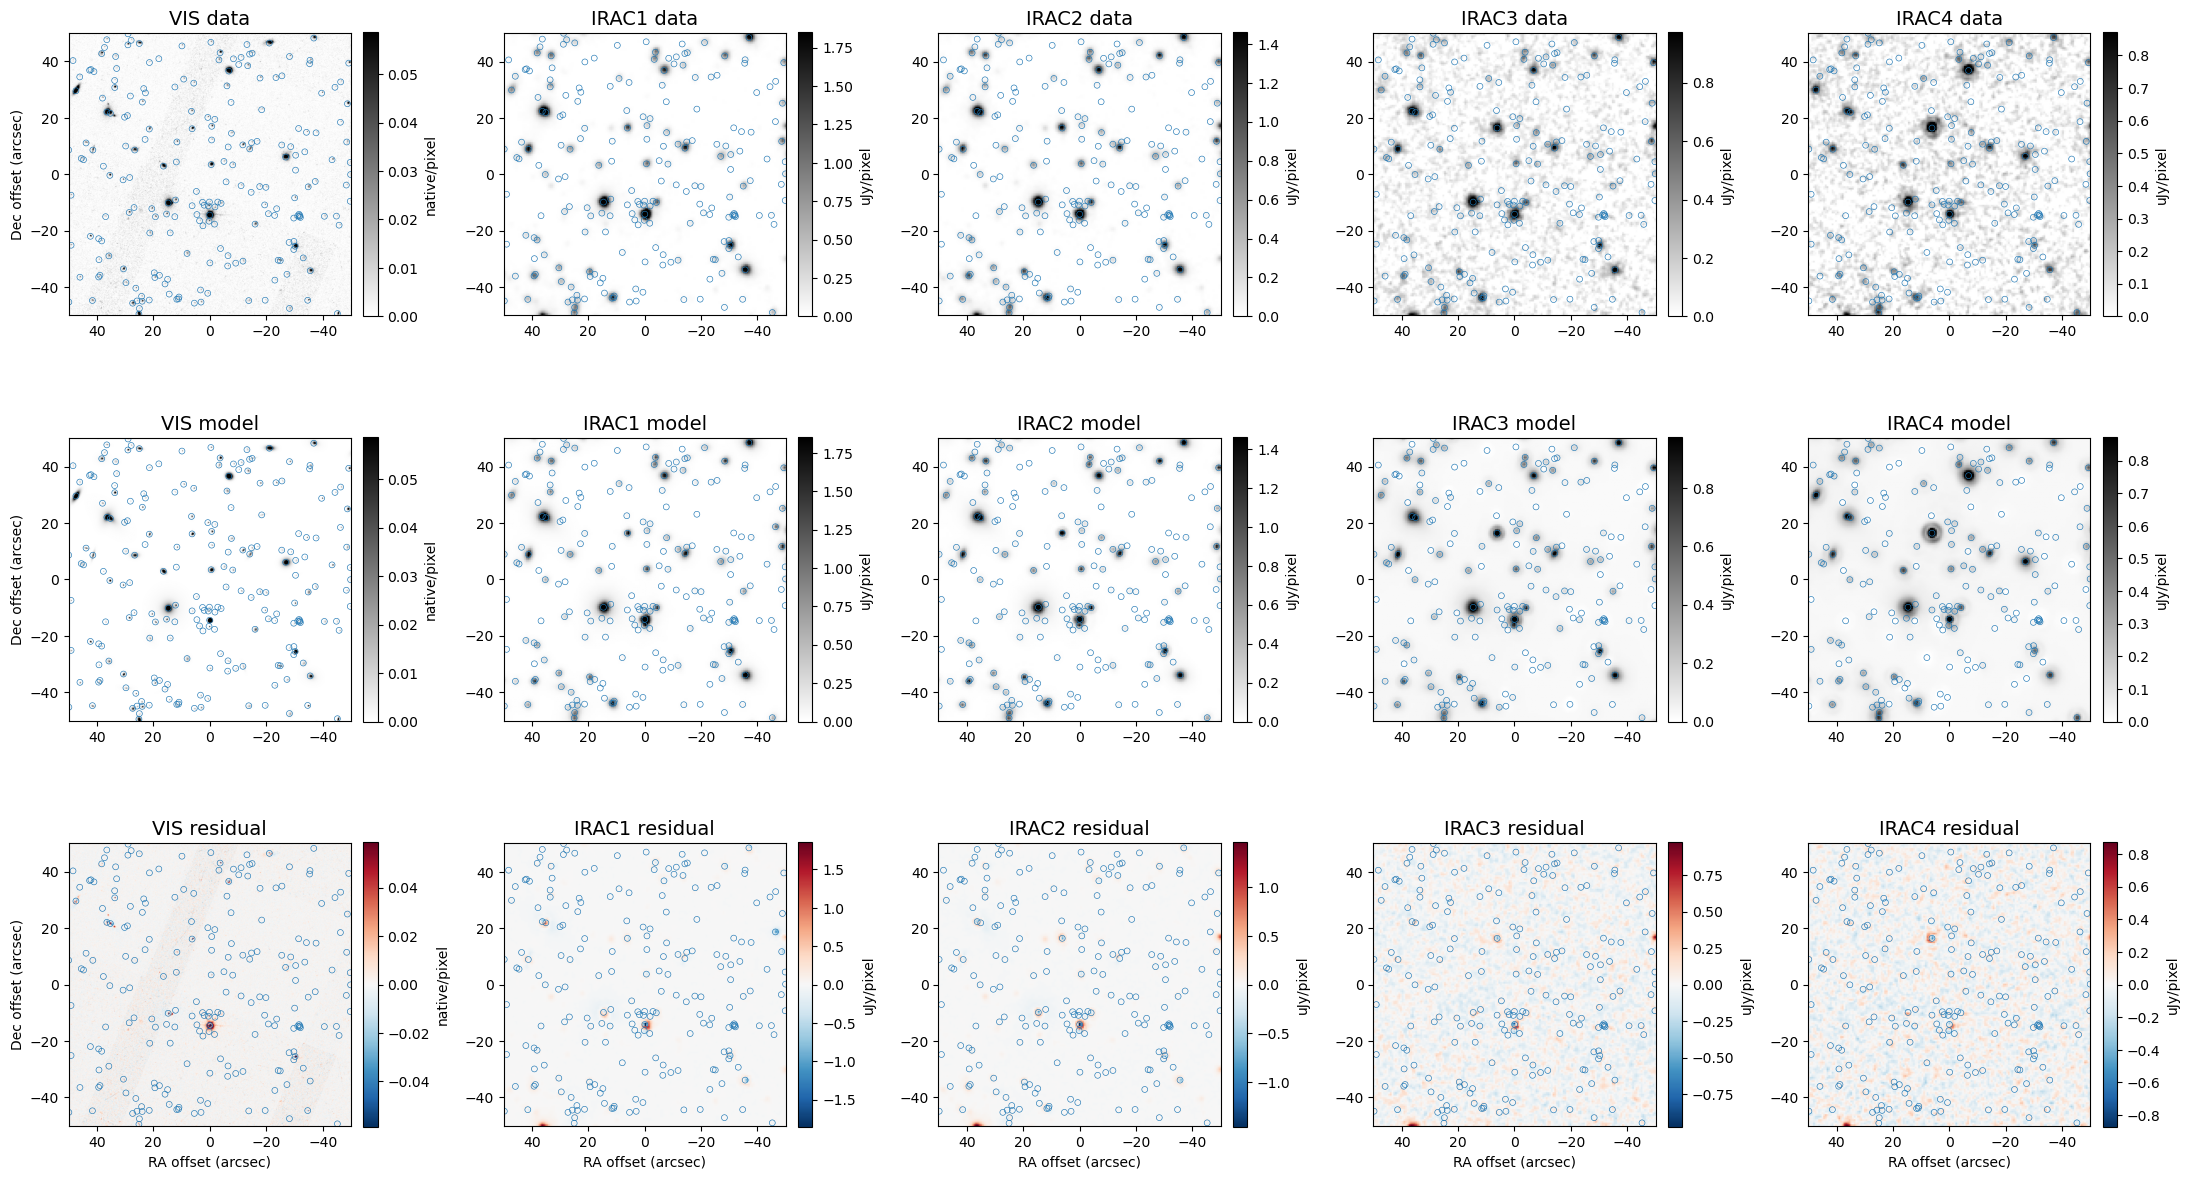

In [4]:
irac.viz.show_fit(run, CHANNELS, size_arcsec=100.0)
plt.show()

## 4. Catalog

One row per VIS source, with flux, error and S/N in each channel. Fluxes
are in microJansky. The table also records the number of exposures, the
coverage, and the centroid shift. `run.save_images()` writes the full data,
model and residual images.

In [5]:
cols = ["object_id", "prior_ra", "prior_dec", "source_model"]
for channel in CHANNELS:
    key = channel.lower()
    cols += [f"flux_{key}_ujy", f"fluxerr_{key}_ujy", f"snr_{key}"]
catalog.write("irac_photometry.csv", overwrite=True)
print(f"wrote {len(catalog)} sources x {len(catalog.colnames)} columns to irac_photometry.csv")
catalog[cols][:8]

wrote 858 sources x 66 columns to irac_photometry.csv


object_id,prior_ra,prior_dec,source_model,flux_irac1_ujy,fluxerr_irac1_ujy,snr_irac1,flux_irac2_ujy,fluxerr_irac2_ujy,snr_irac2,flux_irac3_ujy,fluxerr_irac3_ujy,snr_irac3,flux_irac4_ujy,fluxerr_irac4_ujy,snr_irac4
int64,float64,float64,str20,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-529320082280920152,52.93200918711366,-28.092015286228907,PointSource,130.37250331255427,2.6090078659364804,49.97014574571174,78.37482845869103,1.5686605273917484,49.96289961411016,44.7976830686148,1.0017751934972314,44.71829943425187,25.844539518373963,0.7345721604097782,35.183118706753994
-529154648281026546,52.91546458814595,-28.10265496931962,PointSource,35.53534328772729,0.7166222400770618,49.587273880735275,21.64088829659018,0.43852329376419114,49.34946125855568,15.12806907799876,0.5608575002115289,26.973106488356077,8.283448538767558,0.5584484066459298,14.832970136880473
-529224813280950777,52.922480998665534,-28.09508007886465,PointSource,39.30930503485977,0.7895953397775309,49.784114792186074,20.500829973583162,0.41373848965345345,49.550212238543764,13.846382478132062,0.49623571555794777,27.902833359271085,7.214751916445734,0.5369136785211277,13.437452248037356
-529579574281031082,52.95795745,-28.10310824,ExpGalaxy,40.254922760782975,0.8068260716622906,49.89293749252105,21.470167607871023,0.43149724020359864,49.75736947411411,17.055295394533015,0.49861164897603716,34.20556946384676,6.967026729476105,0.48994873054441634,14.219909747974148
-529272473281119379,52.92725327245503,-28.111934848606186,SersicGalaxy,340.55016042840174,6.813793225392177,49.97952669877224,273.71303371433356,5.475932306954615,49.98473654736546,156.6550484804612,3.2317738940120413,48.47339375156099,93.96093970265574,2.1041549887221374,44.654951848256495
-529554580281022487,52.95545640490869,-28.102250809827883,PointSource,13.249537164355035,0.2680971881810496,49.42064948255796,7.460953069695138,0.1541049424438891,48.41475523999974,3.5857663898466745,0.3804226701350138,9.425743183428235,3.657710865673794,0.4876188732026733,7.501167544336431
-529484631281077410,52.948463355112594,-28.10774101274363,SersicGalaxy,0.08148714874804835,0.02857404618109065,2.8517889357221597,0.14509184760929072,0.03414154771708804,4.249715004474487,-0.4070514127858385,0.3980219692900499,-1.0226857917212318,0.5870441220641722,0.6083241827208378,0.9650185521780728
-529513109281135523,52.95131099,-28.1135523,SersicGalaxy,-0.1260352251346793,0.030494386224714433,-4.133063187628055,-0.28780780139904166,0.04428109095798975,-6.499564377763185,-2.3003091429397924,0.4891489733351371,-4.7026760114729935,0.03625855090710956,0.6998248427195125,0.05181089423206125


## 5. Comparison with the DAWN catalog

The Cosmic Dawn Survey PL catalog has IRAC1 and IRAC2 fluxes in EDF-N and
EDF-F; skip this section for other fields. Sources matched within
0.6 arcsec are compared when both fluxes have S/N ≥ 3, DAWN marks them
valid, and no other VIS source lies within 6 arcsec. The two catalogs use
different source models, PRFs and deblending, so this is a cross-check
rather than a calibration.

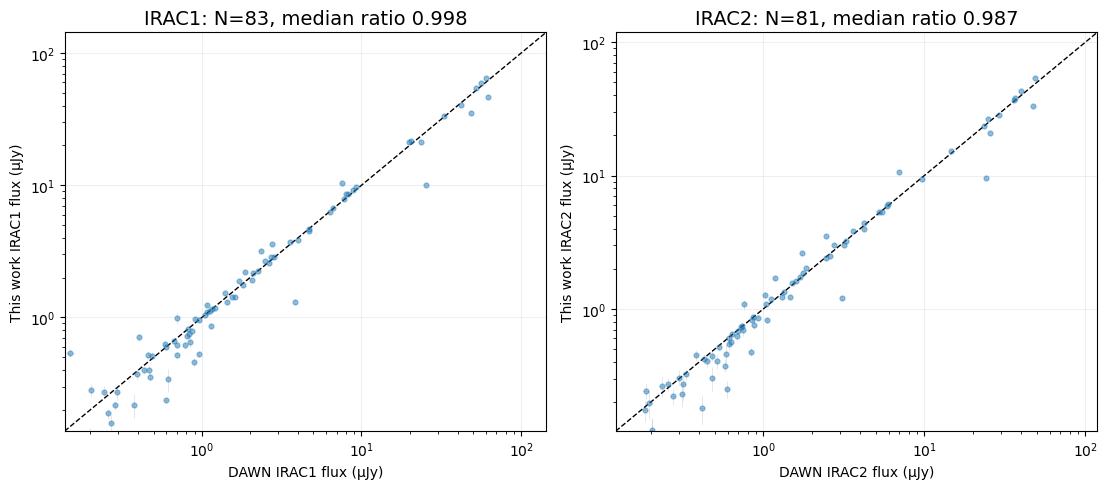

In [6]:
dawn_path = irac.fetch_dawn_pl_catalog(DAWN_FIELD, IRAC_DIR / "catalogs")
dawn = irac.read_dawn_region(dawn_path, TARGET_RA, TARGET_DEC,
                             radius_arcsec=np.sqrt(2) * SIZE_ARCSEC / 2 + 5)
comparisons = irac.compare_dawn(catalog, dawn)
irac.viz.show_dawn_comparison(comparisons)
plt.show()

### Individual sources

The table ranks the comparison sample with S/N ≥ 5 in both catalogs by
|log10(flux ratio)|. Any other selection on `catalog` works the same way.

In [7]:
targets = irac.select_dawn_disagreements(comparisons["IRAC1"], "IRAC1",
                                         minimum_snr=5.0, top_n=10)
targets

object_id,prior_ra,prior_dec,source_model,flux_irac1_ujy,fluxerr_irac1_ujy,dawn_irac1_flux_ujy,dawn_irac1_fluxerr_ujy,snr,dawn_snr,over_dawn,disagreement_dex,difference_sigma,nearest_prior_arcsec,dawn_match_sep_arcsec
int64,float64,float64,str20,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-529161247280990803,52.916125135103435,-28.09908103501944,ExpGalaxy,0.5391939655407074,0.038594704589040074,0.14886453177833683,0.012170077301561832,13.97067217593952,12.232012015176968,3.6220445468070346,0.5589537873125267,9.645376066182479,9.299927729530044,0.04638285936305537
-529293545281117804,52.929342344456245,-28.111762307994738,SersicGalaxy,1.316909378038676,0.05798818181132146,3.832765879338333,0.015179083682596684,22.709961528429332,252.5031128020412,0.34359243937592654,0.4639564012245005,-41.97156994665631,6.662461007647629,0.07227914641233259
-529514347280789974,52.95142909253672,-28.078999091008793,ExpGalaxy,9.994272445914696,0.20275017764809514,25.458176301126336,0.05026129260659218,49.293532374907855,506.5165454536537,0.3925761345863774,0.4060761054809952,-74.02995117016025,6.339495125115699,0.011724191664266557
-529180952281095975,52.91809512720924,-28.109605232930125,ExpGalaxy,0.2363874790004703,0.00996542655273954,0.592718914253979,0.01320127584040165,23.720758740175185,44.89860839359187,0.39881885547384216,0.3992243171741648,-21.54315260091771,7.031060543426942,0.008257783551002333
-529319759280967214,52.93197940390657,-28.096721777177883,ExpGalaxy,0.4564935964783333,0.035913556115747994,0.8957722152741555,0.012513959780335426,12.710899333028237,71.58183588553496,0.5096090152099897,0.29276289774232883,-11.550438059982058,6.324938426586049,0.09113539557312791
-529472493280768369,52.947253564000576,-28.07681906586127,ExpGalaxy,0.5251776257852775,0.0230726530718293,0.9568290737413382,0.012172662653028965,22.7619088342509,78.60474745870388,0.5488729807631765,0.26052814760110293,-16.546739315063988,6.267729826138211,0.028915983236555923
-529163938281154353,52.91639146717128,-28.115438887598145,ExpGalaxy,0.3412093958404688,0.06710492711698351,0.6108491691884715,0.012537900358438492,5.084714498618574,48.720212453861656,0.5585820740229115,0.25291300575970266,-3.9498300097516,7.292833091373964,0.03707574938795897
-529183560280865651,52.91835834655497,-28.086565824294947,FixedCompositeGalaxy,0.7074265162993292,0.047918066295556117,0.405327504126751,0.008639627136290073,14.763252589033113,46.91493020852772,1.7453207815823621,0.24187525987269992,6.204450012157699,6.500536157573841,0.020310575690737107
-529514683280835299,52.95146349023596,-28.08352647520276,ExpGalaxy,0.15787901808145807,0.026160795759841263,0.27050629109035124,0.007571530528366566,6.034947083827394,35.72676489606766,0.583642685148218,0.23385295316237412,-4.135470691717544,6.7387430155648556,0.043416496643981374


A 15 arcsec view of the fourth-ranked source; any position inside the
field works. `run.save_cutout` writes one FITS file per band with data,
uncertainty, model, residual and inverse-variance extensions.

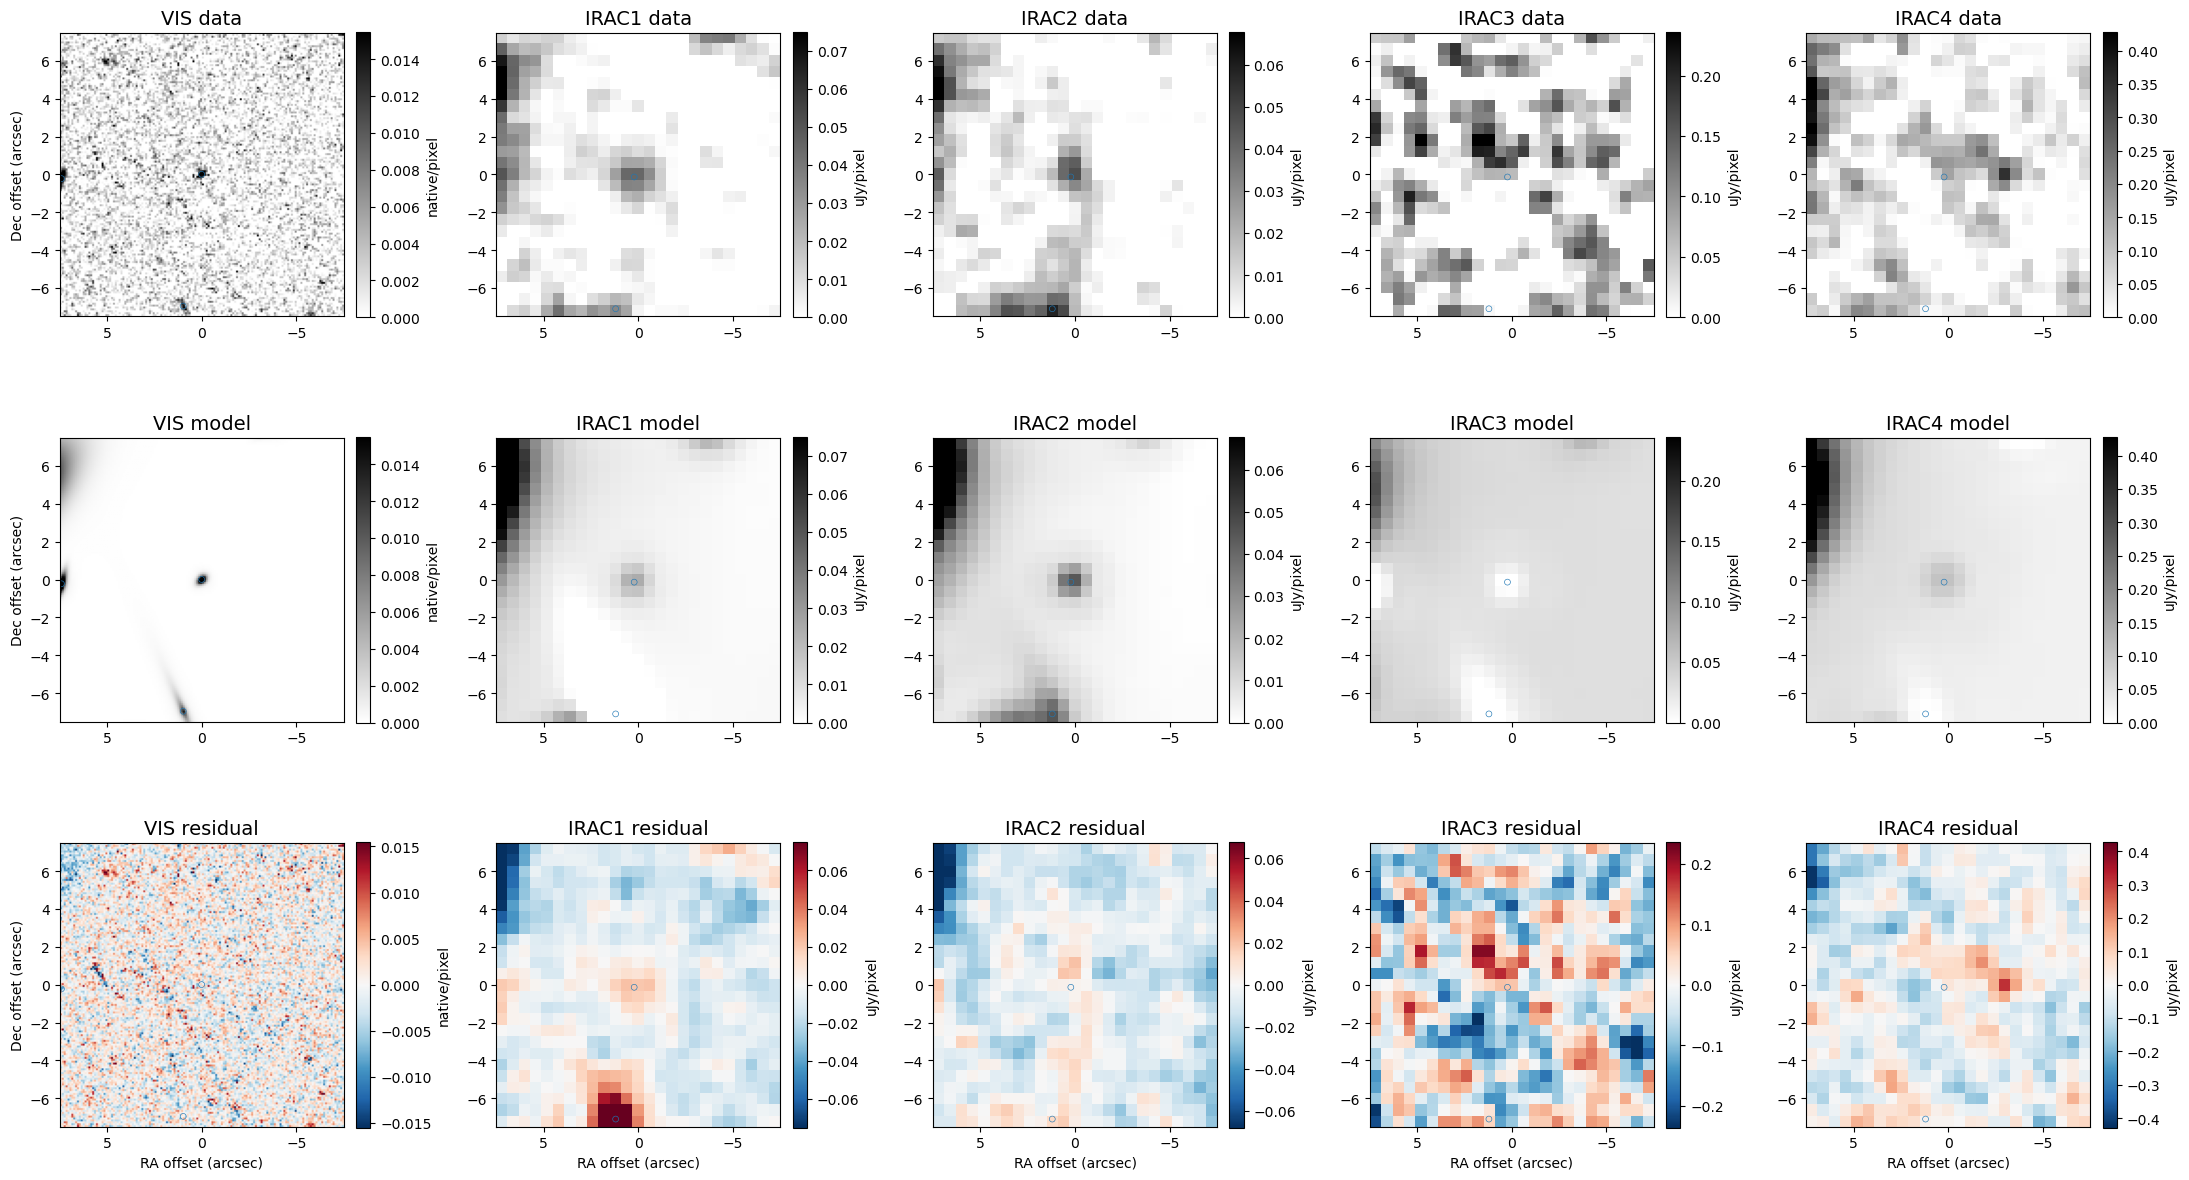

In [8]:
i = min(3, len(targets) - 1)
CUTOUT_RA, CUTOUT_DEC = float(targets["prior_ra"][i]), float(targets["prior_dec"][i])
irac.viz.show_fit(run, CHANNELS, ra=CUTOUT_RA, dec=CUTOUT_DEC, size_arcsec=15.0)
plt.show()
# run.save_cutout("IRAC1", CUTOUT_RA, CUTOUT_DEC, 15.0, overwrite=True)

## 6. Comparison with unWISE

W1 (3.4 µm) and W2 (4.6 µm) lie close to IRAC1 (3.6 µm) and IRAC2
(4.5 µm), and both fits use the same VIS models. The unWISE PSF is about
6.5 arcsec wide, four times the IRAC PRF, so blended neighbours divide
their light differently in the two surveys.

All sources with positive fluxes are shown. The blue sample is selected on
IRAC alone: S/N ≥ 5 in IRAC and an IRAC flux at least five times the WISE
error. A cut on WISE S/N would keep faint sources only when WISE assigned
them extra flux, and bias the ratio high. Ringed sources also have no VIS
neighbour brighter than a third of their flux within two WISE FWHM
(13.9 arcsec), the isolation criterion of notebook 03; few pass it at
Euclid depth.

The bandpasses differ, so offsets that depend on source colour are
expected: for a Rayleigh-Jeans spectrum W1/IRAC1 is about 1.12 and
W2/IRAC2 about 0.96. The flux conventions also differ: unWISE fluxes use
the full PSF stamp, and IRAC fluxes include the Handbook correction to
infinite aperture.

The summed flux over all sources is the cleaner test of calibration,
since it does not depend on how blends are divided. Faint VIS sources next to
bright ones can receive much of their neighbours' WISE flux; they form
the cloud above the line at faint IRAC fluxes.

summed W1/IRAC1 over 857 sources: 1.102
summed W2/IRAC2 over 857 sources: 0.989


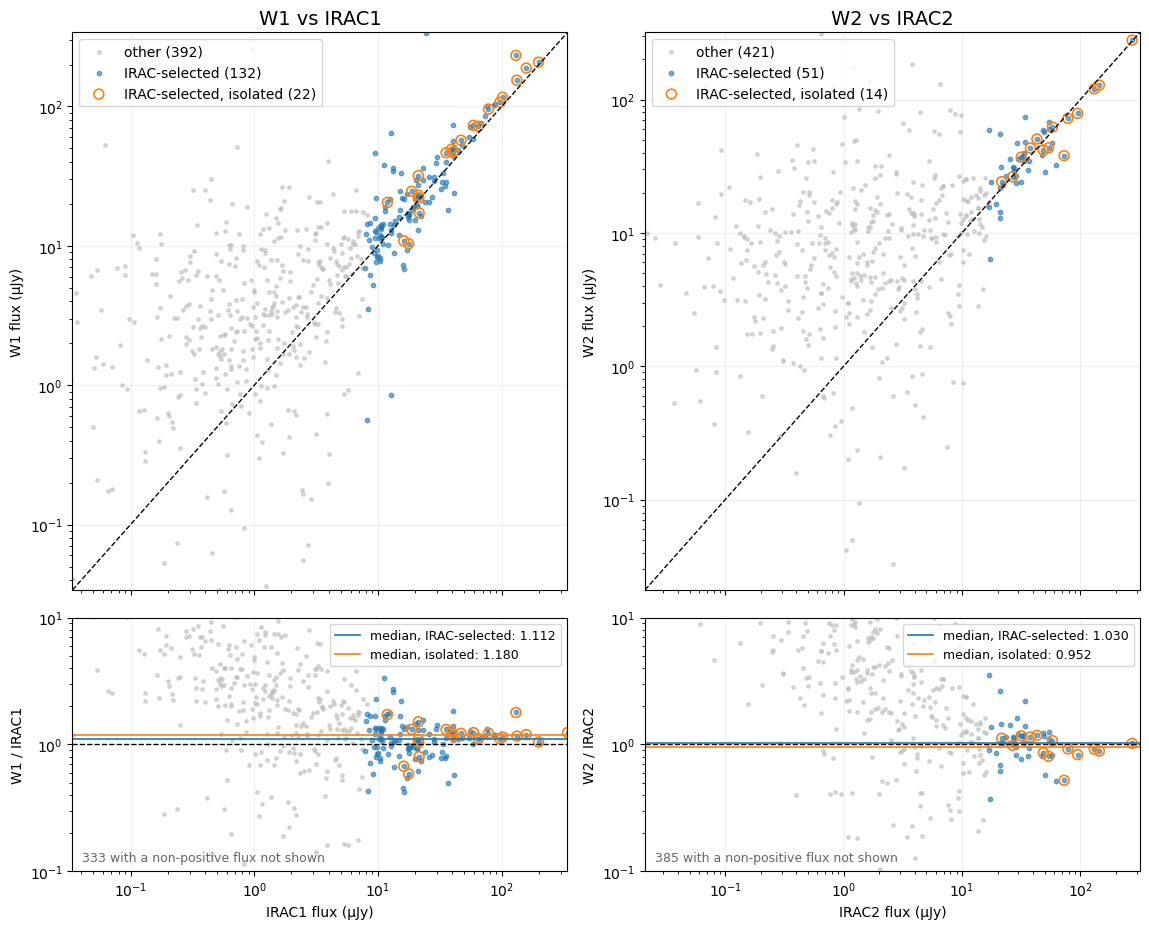

In [9]:
wise_comparisons = irac.compare_wise_irac(catalog)
for wise_band, channel in irac.WISE_IRAC_PAIRS.items():
    w = np.asarray(catalog[f"flux_{wise_band.lower()}_ujy"], float)
    c = np.asarray(catalog[f"flux_{channel.lower()}_ujy"], float)
    both = np.isfinite(w) & np.isfinite(c)
    print(f"summed {wise_band}/{channel} over {both.sum()} sources: "
          f"{w[both].sum() / c[both].sum():.3f}")
irac.viz.show_wise_irac_comparison(wise_comparisons)
plt.show()

## 7. Limitations

### Effective PRF

The PRF grid is built from the detector PRFs and the exposures in each
mosaic. Each stamp is centred, resampled to the mosaic pixels and
normalized to unit sum; the Handbook core-PRF correction is then applied
to the fitted fluxes.

To test the grid, an IRAC1 fit on SEIP was repeated with only the PRF
replaced by the DAWN PRF. For 663 sources with S/N ≥ 3 in both fits, the
median flux difference was −0.08% with a scatter of 2.1%; the apparent
trend comes from the larger errors of faint sources. This scatter sets the
2% systematic included in `fluxerr_<channel>_ujy`.

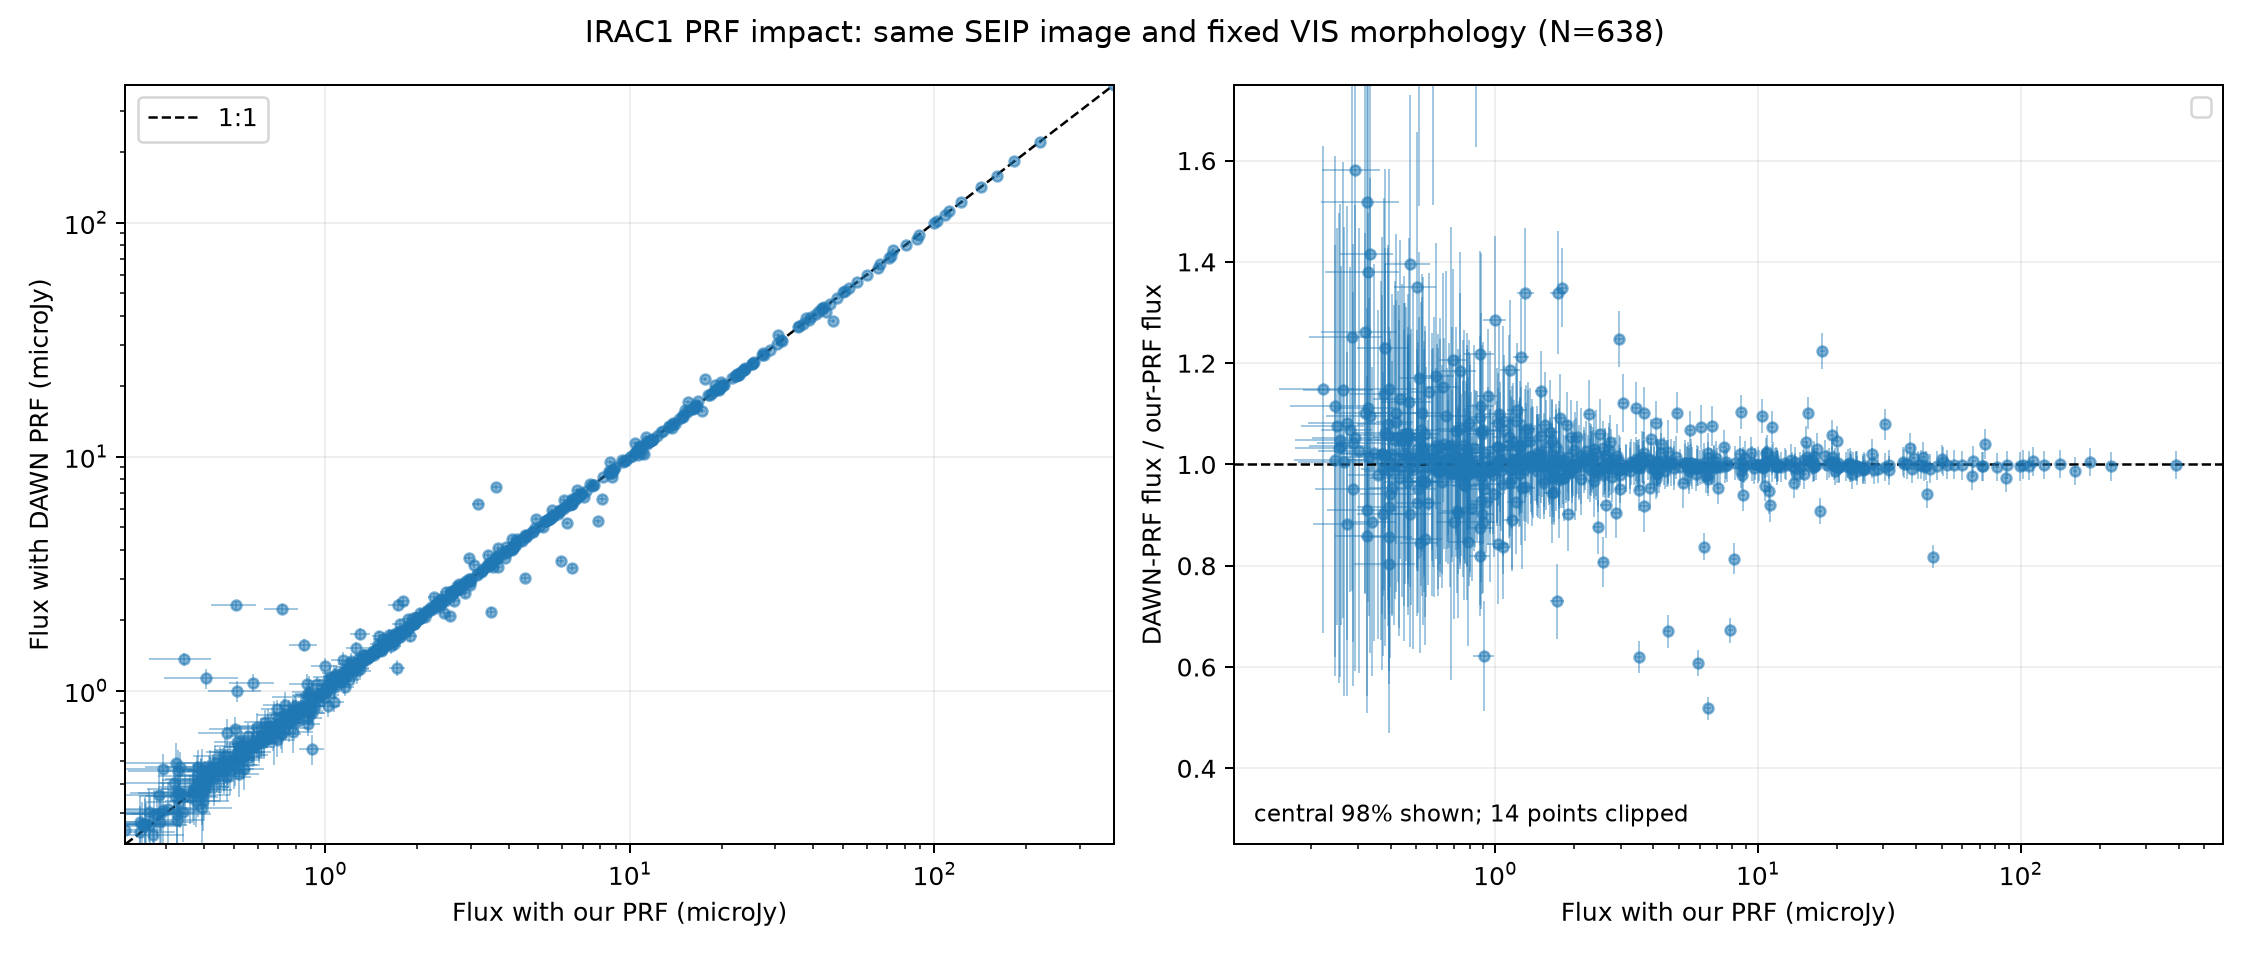

### Morphology prior

IRAC is strongly blended, so the VIS models decide how flux is divided
between neighbours. To test this, VIS was degraded to ground-based quality
(0.70 arcsec seeing, 0.168 arcsec pixels) and the models were selected
again. The median ratio to DAWN became 1.008 (N = 81) in IRAC1 and 1.025
(N = 77) in IRAC2, but individual sources scattered by about 25%. The
morphology prior moves the median by a few percent and individual fluxes
by much more.

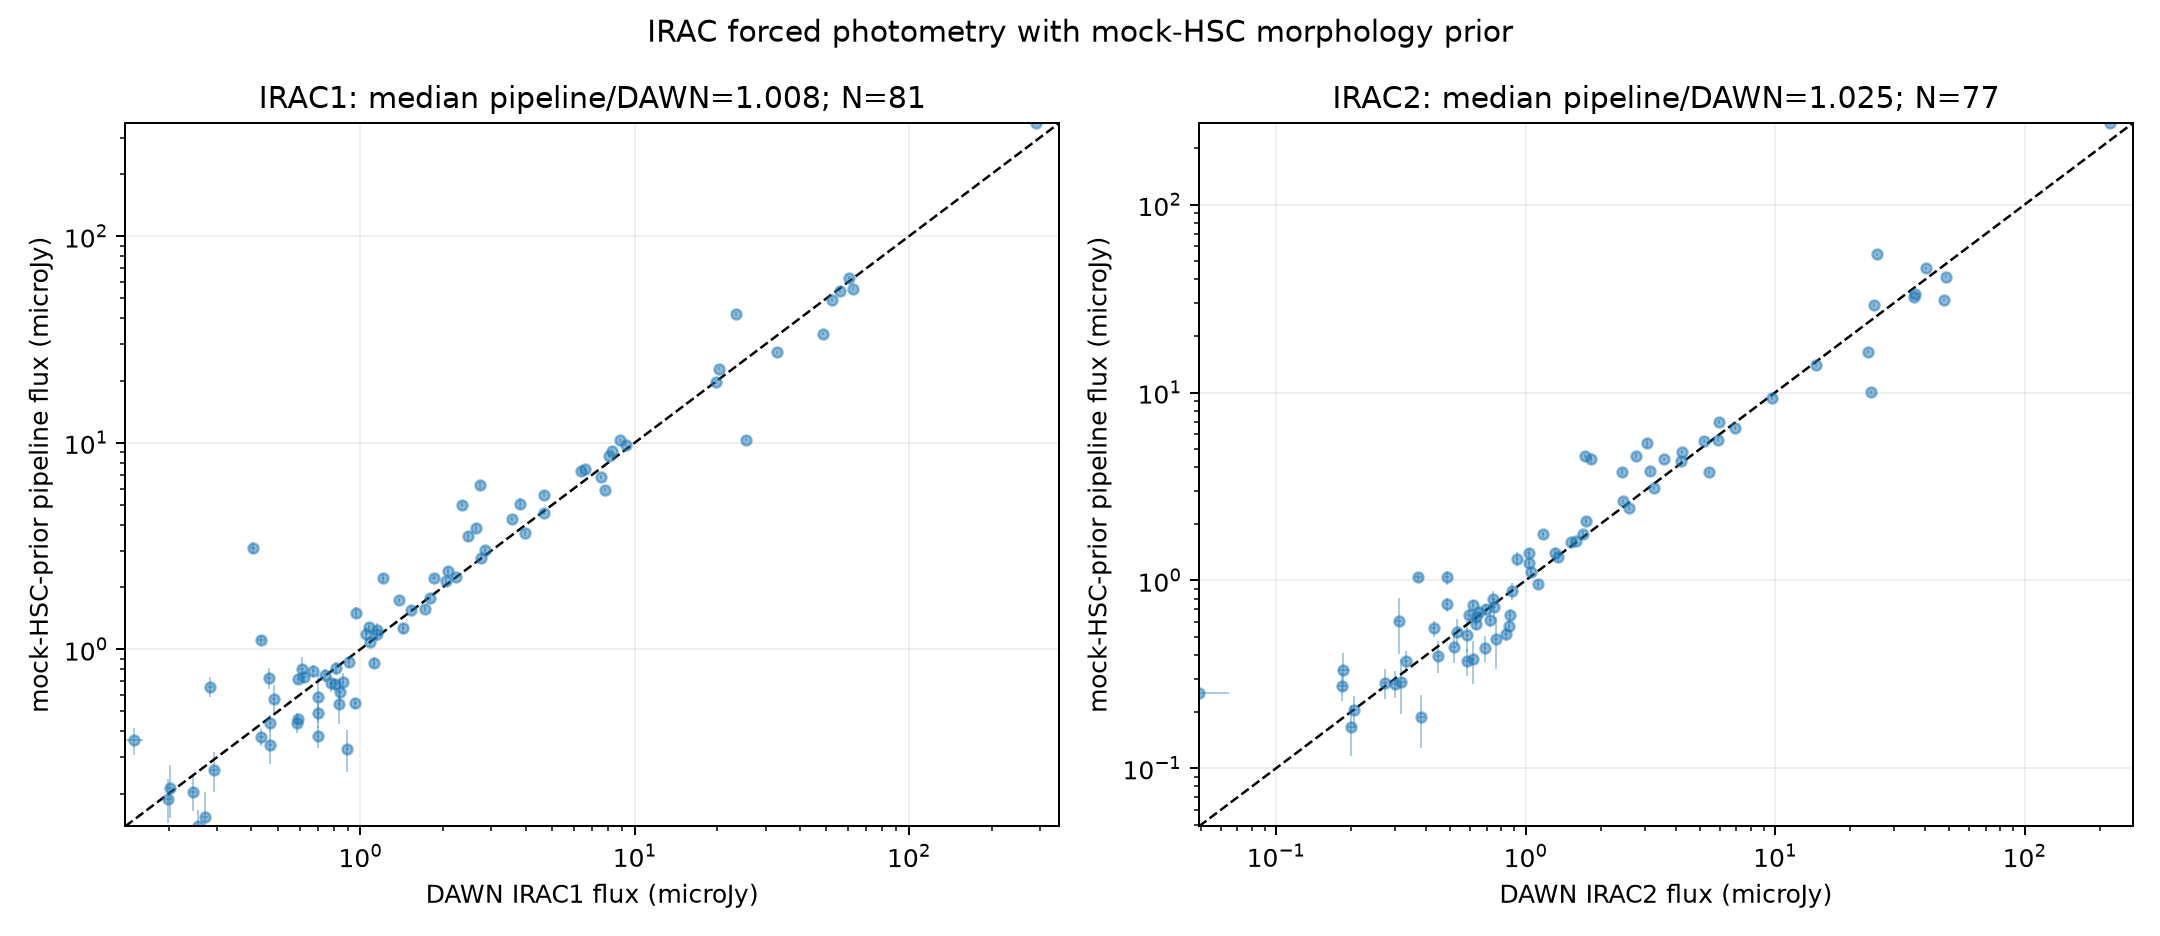